In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns
from itertools import product
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

## General setup

In [54]:
class BooleanNetwork:
    def __init__(self, node_names):
        self.nodes = {name: 0 for name in node_names}
        self.rules = {}
        self.history = []
        self.graph = nx.DiGraph()  # NetworkX graph for visualization

        # Add nodes to NetworkX graph
        self.graph.add_nodes_from(node_names)

    def add_rule(self, target_node, rule_function, rule_description=""):
        """
        Add Boolean rule for a node

        Args:
            target_node: Node to update
            rule_function: Function that takes current state dict and returns True/False
            rule_description: Human-readable description
        """
        self.rules[target_node] = {
            'function': rule_function,
            'description': rule_description
        }

    def set_state(self, **kwargs):
        """Set states of specific nodes"""
        for node, value in kwargs.items():
            if node in self.nodes:
                self.nodes[node] = int(bool(value))

    def get_state_vector(self):
        """Get current state as list in sorted order"""
        return [self.nodes[node] for node in sorted(self.nodes.keys())]

    def update_synchronous(self):
        """Update all nodes simultaneously"""
        new_state = {}
        for node in self.nodes:
            if node in self.rules:
                new_state[node] = int(self.rules[node]['function'](self.nodes))
            else:
                new_state[node] = self.nodes[node]  # No rule = no change

        self.nodes = new_state
        self.history.append(self.get_state_vector())

    def simulate(self, steps=10, record_history=True):
        """Run simulation"""
        if record_history:
            self.history = [self.get_state_vector()]

        for step in range(steps):
            self.update_synchronous()

            # Check for steady state
            if len(self.history) >= 2 and self.history[-1] == self.history[-2]:
                print(f"   Reached steady state after {step+1} steps")
                break

        return np.array(self.history)

In [55]:
def reset_network():
    nodes = ['DNA_damage', 'p53', 'MYC', 'CDK2', 'MDM2', 'p21', 'Growth', 'Death']
    network = BooleanNetwork(nodes)

    # Define Boolean rules (based on real biology, simplified)
    network.add_rule('DNA_damage', lambda s: s['DNA_damage'], "DNA_damage = INPUT (constant)")
    network.add_rule('p21', lambda s: s['p53'], "p21 = p53")
    network.add_rule('MYC', lambda s: (not s['p53']) and (not s['p21']), "MYC = (NOT p53) AND (NOT p21)")
    network.add_rule('CDK2', lambda s: s['MYC'] and (not s['p21']) and (not s['p53']), "CDK2 = MYC AND (NOT p21) AND (NOT p53)")
    network.add_rule('MDM2', lambda s: s['MYC'], "MDM2 = MYC")
    network.add_rule('p53', lambda s: s['DNA_damage'] and not s['MDM2'], "p53 = DNA_damage AND (NOT MDM2)")
    network.add_rule('Growth',lambda s: s['CDK2'] and s['MYC'] and (not s['p53']), "Growth = CDK2 AND MYC AND (NOT p53)")
    network.add_rule('Death', lambda s: s['p53'] and s['DNA_damage'] and (not s['Growth']), "Death = p53 AND DNA_damage AND (NOT Growth)")
    return network
network = reset_network()

print("Rules:")
for node, rule_info in network.rules.items():
    print(f" {rule_info['description']}")

Rules:
 DNA_damage = INPUT (constant)
 p21 = p53
 MYC = (NOT p53) AND (NOT p21)
 CDK2 = MYC AND (NOT p21) AND (NOT p53)
 MDM2 = MYC
 p53 = DNA_damage AND (NOT MDM2)
 Growth = CDK2 AND MYC AND (NOT p53)
 Death = p53 AND DNA_damage AND (NOT Growth)


### Testing the first mutation: p53 Knockout

##### Scenario analysis

In [56]:
network = reset_network()
network.add_rule('p53', lambda s: False, "p53 = BROKEN (always OFF)")

print("Rules:") 
for node, rule_info in network.rules.items():
    print(f" {rule_info['description']}")

Rules:
 DNA_damage = INPUT (constant)
 p21 = p53
 MYC = (NOT p53) AND (NOT p21)
 CDK2 = MYC AND (NOT p21) AND (NOT p53)
 MDM2 = MYC
 p53 = BROKEN (always OFF)
 Growth = CDK2 AND MYC AND (NOT p53)
 Death = p53 AND DNA_damage AND (NOT Growth)


In [57]:
scenarios = {
    'Healthy Cell': {'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Stressed Cell': { 'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Oncogene Hijacked Cell': { 'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}
}

results = {}

# Run healthy cell scenario
s1 = "Healthy Cell"
s2 = "Stressed Cell"
s3 = "Oncogene Hijacked Cell"

for s in [s1, s2, s3]:
    initial_state = scenarios[s]

    network.set_state(**initial_state)
    trajectory = network.simulate(steps=8)
    results[s] = trajectory

    final_state = trajectory[-1]
    node_names = sorted(network.nodes.keys())
    final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

    print(f"   {s}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")

   Reached steady state after 4 steps
   Healthy Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 4 steps
   Stressed Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 3 steps
   Oncogene Hijacked Cell: Final state: Growth=1, Death=0, p53=0


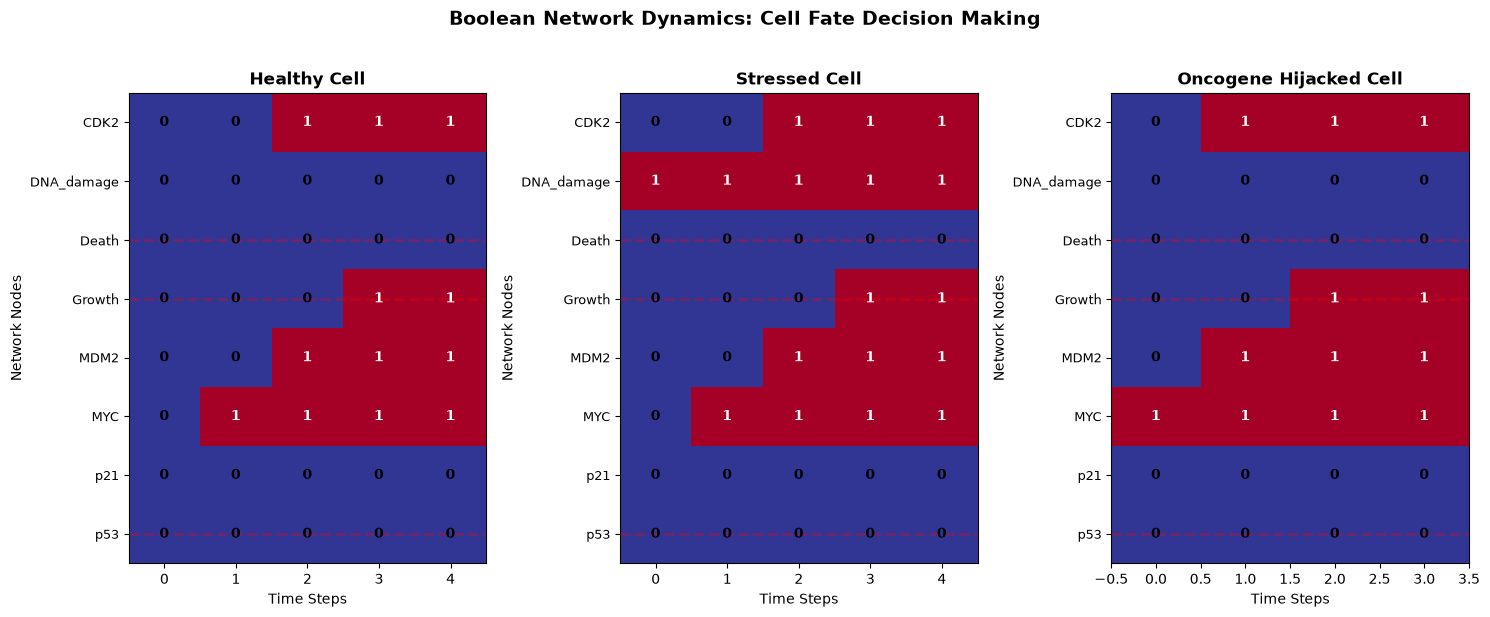

In [58]:
n_scenarios = len(results)
fig, axes = plt.subplots(1, n_scenarios, figsize=(5*n_scenarios, 6))

if n_scenarios == 1:
    axes = [axes]

for scenario_idx, (scenario_name, trajectory) in enumerate(results.items()):
    ax = axes[scenario_idx]

    # Create heatmap
    trajectory_matrix = trajectory.T  # Transpose for proper orientation

    im = ax.imshow(trajectory_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')

    # Formatting
    ax.set_title(f'{scenario_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Time Steps', fontsize=10)
    ax.set_ylabel('Network Nodes', fontsize=10)
    ax.set_yticks(range(len(node_names)))
    ax.set_yticklabels(node_names, fontsize=9)

    # Add text annotations
    for t in range(trajectory.shape[0]):
        for n in range(len(node_names)):
            color = 'white' if trajectory_matrix[n, t] == 1 else 'black'
            ax.text(t, n, int(trajectory_matrix[n, t]),
                   ha="center", va="center", color=color, fontweight='bold')

    # Highlight key output nodes
    output_indices = [i for i, name in enumerate(node_names) if name in ['Growth', 'Death', 'p53']]
    for output_idx in output_indices:  # Changed variable name to avoid conflict
        ax.axhline(y=output_idx, color='red', linestyle='--', alpha=0.3, linewidth=2)

plt.suptitle('Boolean Network Dynamics: Cell Fate Decision Making',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Analysis: In all three cases cells end up in a growth state. MYC, MDM2 and CDK2 are always activated. A steady state is reached after 4 steps for "Stressed cells" and "Healthy Cell" and after 3 steps for "Oncogene Hijacked Cell".

##### Attractor analysis

In [59]:
import itertools

attractors = []
max_steps=15
node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

print(f"Testing all {2**n_nodes} possible initial states...")

# TODO: Generate all possible initial states
# Hint: Use itertools.product([0, 1], repeat=n_nodes)
all_states = itertools.product([0, 1], repeat=n_nodes)

for initial_state in all_states:
  # Set the network to this initial state
  state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
  network.set_state(**state_dict)

  # TODO: Simulate the network
  trajectory = network.simulate(steps=max_steps)

  # Check if it reached a steady state (last two states are the same)
  if len(trajectory) >= 2:
    final_state = tuple(trajectory[-1])  # Convert to tuple for comparison

  # Check if this is a new attractor
    if np.array_equal(trajectory[-1], trajectory[-2]):  # Steady state reached
      if final_state not in attractors:
        attractors.append(final_state)

Testing all 256 possible initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reac

In [60]:
print(f"\nFOUND {len(attractors)} ATTRACTORS:")

for i, attractor in enumerate(attractors):
    print(f"\nAttractor {i + 1}: {list(attractor)}")

    # Create state dictionary for easy access
    state_dict = {node_names[j]: attractor[j] for j in range(len(node_names))}

    # Analyze the biological meaning
    growth_active = state_dict['Growth'] == 1
    death_active = state_dict['Death'] == 1
    p53_active = state_dict['p53'] == 1
    dna_damage_active = state_dict['DNA_damage'] == 1

    print(f"   Growth: {'ON' if growth_active else 'OFF'}")
    print(f"   Death: {'ON' if death_active else 'OFF'}")
    print(f"   p53: {'ON' if p53_active else 'OFF'}")
    print(f"   DNA Damage: {'ON' if dna_damage_active else 'OFF'}")

    # TODO: Interpret the meaning
    if growth_active and not death_active and not dna_damage_active:
        interpretation = "Cancer-like growth state"
    elif death_active and not growth_active:
        interpretation = "Cell death / protective state"
    elif growth_active and not death_active and dna_damage_active:
        interpretation = "Cancer-like growth despite DNA damage"
    else:
        interpretation = "CONFLICT - Unusual state"

    print(f"   → {interpretation}")
# Convert attractors to clean matrix
attractor_matrix = []
for attractor in attractors:
    clean_row = [int(x) for x in attractor]
    attractor_matrix.append(clean_row)

attractor_matrix = np.array(attractor_matrix)

# Create heatmap
plt.figure(figsize=(10, max(6, len(attractors))))

# Create heatmap with custom colors
ax = sns.heatmap(attractor_matrix,
                 xticklabels=node_names,
                 yticklabels=[f'Attractor {i + 1}' for i in range(len(attractors))],
                 cmap='RdYlBu_r',
                 cbar_kws={'label': 'Node State (0=OFF, 1=ON)'},
                 annot=True,
                 fmt='d',
                 linewidths=0.5)

plt.title('Boolean Network Attractors: Final States Comparison',
          fontsize=14, fontweight='bold')
plt.xlabel('Network Nodes', fontsize=12)
plt.ylabel('Attractors', fontsize=12)

# Highlight key output nodes
output_nodes = ['Growth', 'Death', 'p53', 'DNA_damage']
for node in output_nodes:
    if node in node_names:
        idx = node_names.index(node)
        ax.axvline(x=idx + 0.5, color='red', linestyle='--', alpha=0.7, linewidth=2)

plt.tight_layout()
plt.show()


FOUND 2 ATTRACTORS:

Attractor 1: [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: OFF
   → Cancer-like growth state

Attractor 2: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: ON
   → Cancer-like growth despite DNA damage


TypeError: 'int' object is not callable

Analyzing 256 initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady 

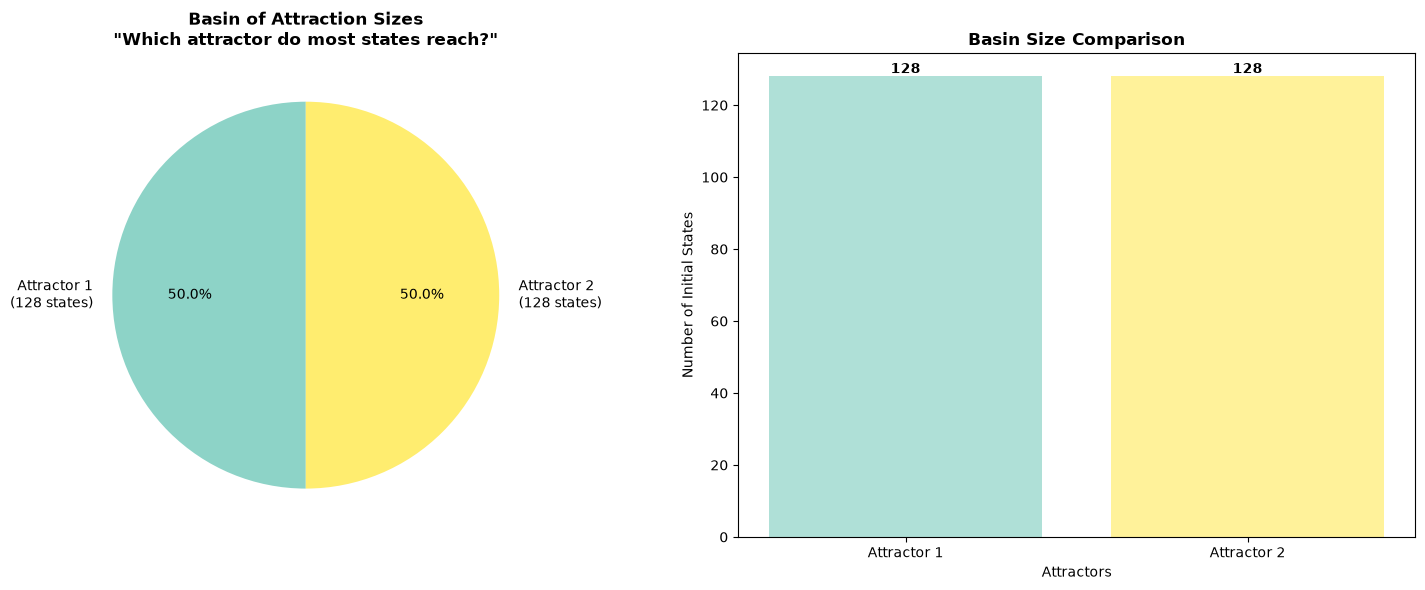

In [ ]:
# Track which initial states lead to which attractors
basin_data = defaultdict(list)  # attractor -> list of initial states
attractor_map = {}  # initial_state -> attractor_index

n_nodes = len(node_names)
all_states = list(product([0, 1], repeat=n_nodes))
print(f"Analyzing {len(all_states)} initial states...")

for initial_state in all_states:
    # Set network state
    state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
    network.set_state(**state_dict)

    # Simulate
    trajectory = network.simulate(steps=max_steps, record_history=True)

    # Find which attractor this leads to
    if len(trajectory) >= 2 and np.array_equal(trajectory[-1], trajectory[-2]):
        final_state = tuple(int(x) for x in trajectory[-1])  # Clean conversion

        # Find matching attractor
        for att_idx, attractor in enumerate(attractors):
            clean_attractor = tuple(int(x) for x in attractor)
            if final_state == clean_attractor:
                basin_data[att_idx].append(initial_state)
                attractor_map[initial_state] = att_idx
                break

# Display basin sizes
print(f"\n Basin Sizes:")
total_states = len(all_states)
for att_idx in range(len(attractors)):
    basin_size = len(basin_data[att_idx])
    percentage = (basin_size / total_states) * 100
    print(f"   Attractor {att_idx+1}: {basin_size:3d} states ({percentage:5.1f}%)")

# Create pie chart of basin sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart of basin sizes
basin_sizes = [len(basin_data[i]) for i in range(len(attractors))]
basin_labels = [f'Attractor {i+1}\n({size} states)' for i, size in enumerate(basin_sizes)]
colors = plt.cm.Set3(np.linspace(0, 1, len(attractors)))

wedges, texts, autotexts = ax1.pie(basin_sizes,
                                   labels=basin_labels,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)

ax1.set_title('Basin of Attraction Sizes\n"Which attractor do most states reach?"',
              fontsize=12, fontweight='bold')

# Bar chart comparison
attractor_names = [f'Attractor {i+1}' for i in range(len(attractors))]
bars = ax2.bar(attractor_names, basin_sizes, color=colors, alpha=0.7)

ax2.set_title('Basin Size Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Initial States', fontsize=10)
ax2.set_xlabel('Attractors', fontsize=10)

# Add value labels on bars
for bar, size in zip(bars, basin_sizes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{size}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Analysis: 2 steady states were found, with as only difference the "cell damage". This makes sense because "cell damage" is independent of gene interactions. p21 being completely dependent on p53 never turns on (as p53 is always off), and because of that MYC turns on. As a consequence, MDM2 and CDK2 turn on as well. All states reach one of these two steady states after at most 6 steps.

### Testing the Second mutation: MYC amplification

In [ ]:
network = reset_network()
network.add_rule('MYC', lambda s: True, "MYC = AMPLIFIED (always ON)")

print("Rules:")
for node, rule_info in network.rules.items():
    print(f" {rule_info['description']}")

Rules:
 DNA_damage = INPUT (constant)
 p21 = p53
 MYC = AMPLIFIED (always ON)
 CDK2 = MYC AND (NOT p21) AND (NOT p53)
 MDM2 = MYC
 p53 = DNA_damage AND (NOT MDM2)
 Growth = CDK2 AND MYC AND (NOT p53)
 Death = p53 AND DNA_damage AND (NOT Growth)


In [ ]:
scenarios = {
    'Healthy Cell': {'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Stressed Cell': { 'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Oncogene Hijacked Cell': { 'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}
}

results = {}

# Run healthy cell scenario
s1 = "Healthy Cell"
s2 = "Stressed Cell"
s3 = "Oncogene Hijacked Cell"

for s in [s1, s2, s3]:
    initial_state = scenarios[s]

    network.set_state(**initial_state)
    trajectory = network.simulate(steps=8)
    results[s] = trajectory

    final_state = trajectory[-1]
    node_names = sorted(network.nodes.keys())
    final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

    print(f"   {s}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")

   Reached steady state after 4 steps
   Healthy Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 7 steps
   Stressed Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 3 steps
   Oncogene Hijacked Cell: Final state: Growth=1, Death=0, p53=0


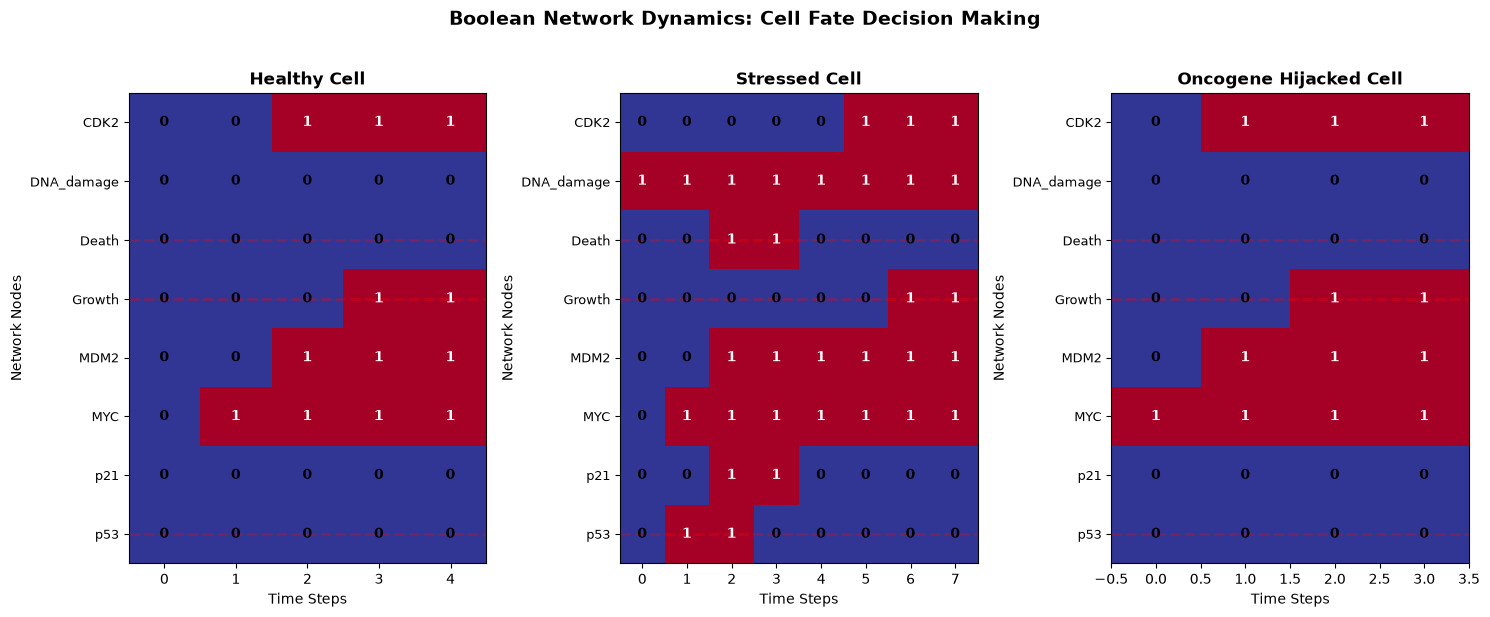

In [ ]:
n_scenarios = len(results)
fig, axes = plt.subplots(1, n_scenarios, figsize=(5*n_scenarios, 6))

if n_scenarios == 1:
    axes = [axes]

for scenario_idx, (scenario_name, trajectory) in enumerate(results.items()):
    ax = axes[scenario_idx]

    # Create heatmap
    trajectory_matrix = trajectory.T  # Transpose for proper orientation

    im = ax.imshow(trajectory_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')

    # Formatting
    ax.set_title(f'{scenario_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Time Steps', fontsize=10)
    ax.set_ylabel('Network Nodes', fontsize=10)
    ax.set_yticks(range(len(node_names)))
    ax.set_yticklabels(node_names, fontsize=9)

    # Add text annotations
    for t in range(trajectory.shape[0]):
        for n in range(len(node_names)):
            color = 'white' if trajectory_matrix[n, t] == 1 else 'black'
            ax.text(t, n, int(trajectory_matrix[n, t]),
                   ha="center", va="center", color=color, fontweight='bold')

    # Highlight key output nodes
    output_indices = [i for i, name in enumerate(node_names) if name in ['Growth', 'Death', 'p53']]
    for output_idx in output_indices:  # Changed variable name to avoid conflict
        ax.axhline(y=output_idx, color='red', linestyle='--', alpha=0.3, linewidth=2)

plt.suptitle('Boolean Network Dynamics: Cell Fate Decision Making',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Analysis: In all three scenarios, the cells end up in a growth state. Because MYC is always ON, it activates MDM2 and CDK2. MDM2 suppresses p53, which also reduces p21 activity. As a result, Growth becomes active and Death stays OFF. This also happens in the stressed cell, meaning that the cell continues growing even when DNA damage is present.

##### Attractor analysis

In [ ]:
import itertools

attractors = []
max_steps = 15
node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

print(f"Testing all {2 ** n_nodes} possible initial states...")

# TODO: Generate all possible initial states
# Hint: Use itertools.product([0, 1], repeat=n_nodes)
all_states = itertools.product([0, 1], repeat=n_nodes)

for initial_state in all_states:
    # Set the network to this initial state
    state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
    network.set_state(**state_dict)

    # TODO: Simulate the network
    trajectory = network.simulate(steps=max_steps)

    # Check if it reached a steady state (last two states are the same)
    if len(trajectory) >= 2:
        final_state = tuple(trajectory[-1])  # Convert to tuple for comparison

        # Check if this is a new attractor
        if np.array_equal(trajectory[-1], trajectory[-2]):  # Steady state reached
            if final_state not in attractors:
                attractors.append(final_state)

Testing all 256 possible initial states...
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reac


FOUND 2 ATTRACTORS:

Attractor 1: [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: OFF
   → Cancer-like growth state

Attractor 2: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: ON
   → Cancer-like growth despite DNA damage


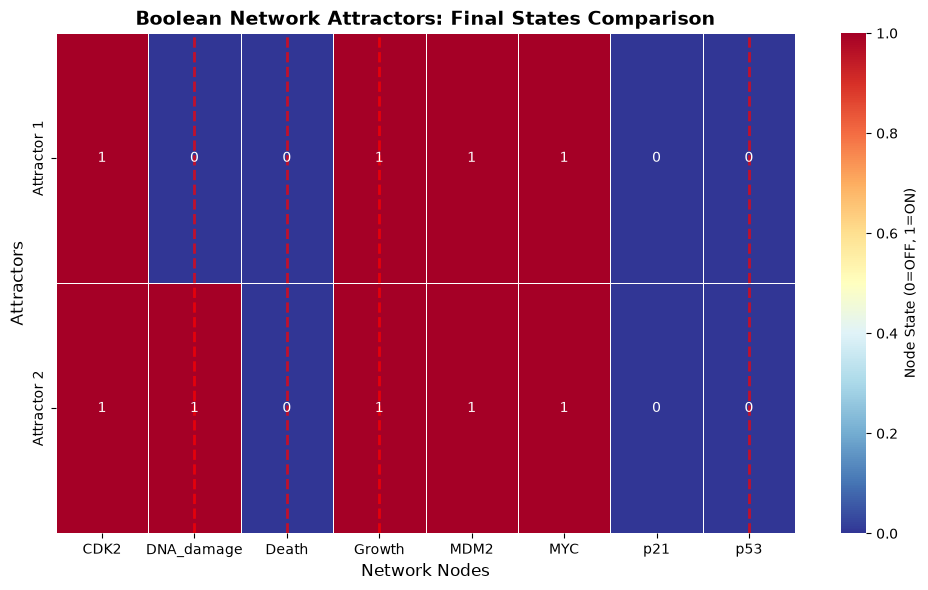

In [ ]:
print(f"\nFOUND {len(attractors)} ATTRACTORS:")

for i, attractor in enumerate(attractors):
    print(f"\nAttractor {i + 1}: {list(attractor)}")

    # Create state dictionary for easy access
    state_dict = {node_names[j]: attractor[j] for j in range(len(node_names))}

    # Analyze the biological meaning
    growth_active = state_dict['Growth'] == 1
    death_active = state_dict['Death'] == 1
    p53_active = state_dict['p53'] == 1
    dna_damage_active = state_dict['DNA_damage'] == 1

    print(f"   Growth: {'ON' if growth_active else 'OFF'}")
    print(f"   Death: {'ON' if death_active else 'OFF'}")
    print(f"   p53: {'ON' if p53_active else 'OFF'}")
    print(f"   DNA Damage: {'ON' if dna_damage_active else 'OFF'}")

    # TODO: Interpret the meaning
    if growth_active and not death_active and not dna_damage_active:
        interpretation = "Cancer-like growth state"
    elif death_active and not growth_active:
        interpretation = "Cell death / protective state"
    elif growth_active and not death_active and dna_damage_active:
        interpretation = "Cancer-like growth despite DNA damage"
    else:
        interpretation = "CONFLICT - Unusual state"

    print(f"   → {interpretation}")
# Convert attractors to clean matrix
attractor_matrix = []
for attractor in attractors:
    clean_row = [int(x) for x in attractor]
    attractor_matrix.append(clean_row)

attractor_matrix = np.array(attractor_matrix)

# Create heatmap
plt.figure(figsize=(10, max(6, len(attractors))))

# Create heatmap with custom colors
ax = sns.heatmap(attractor_matrix,
                 xticklabels=node_names,
                 yticklabels=[f'Attractor {i + 1}' for i in range(len(attractors))],
                 cmap='RdYlBu_r',
                 cbar_kws={'label': 'Node State (0=OFF, 1=ON)'},
                 annot=True,
                 fmt='d',
                 linewidths=0.5)

plt.title('Boolean Network Attractors: Final States Comparison',
          fontsize=14, fontweight='bold')
plt.xlabel('Network Nodes', fontsize=12)
plt.ylabel('Attractors', fontsize=12)

# Highlight key output nodes
output_nodes = ['Growth', 'Death', 'p53', 'DNA_damage']
for node in output_nodes:
    if node in node_names:
        idx = node_names.index(node)
        ax.axvline(x=idx + 0.5, color='red', linestyle='--', alpha=0.7, linewidth=2)

plt.tight_layout()
plt.show()

Analyzing 256 initial states...
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady 

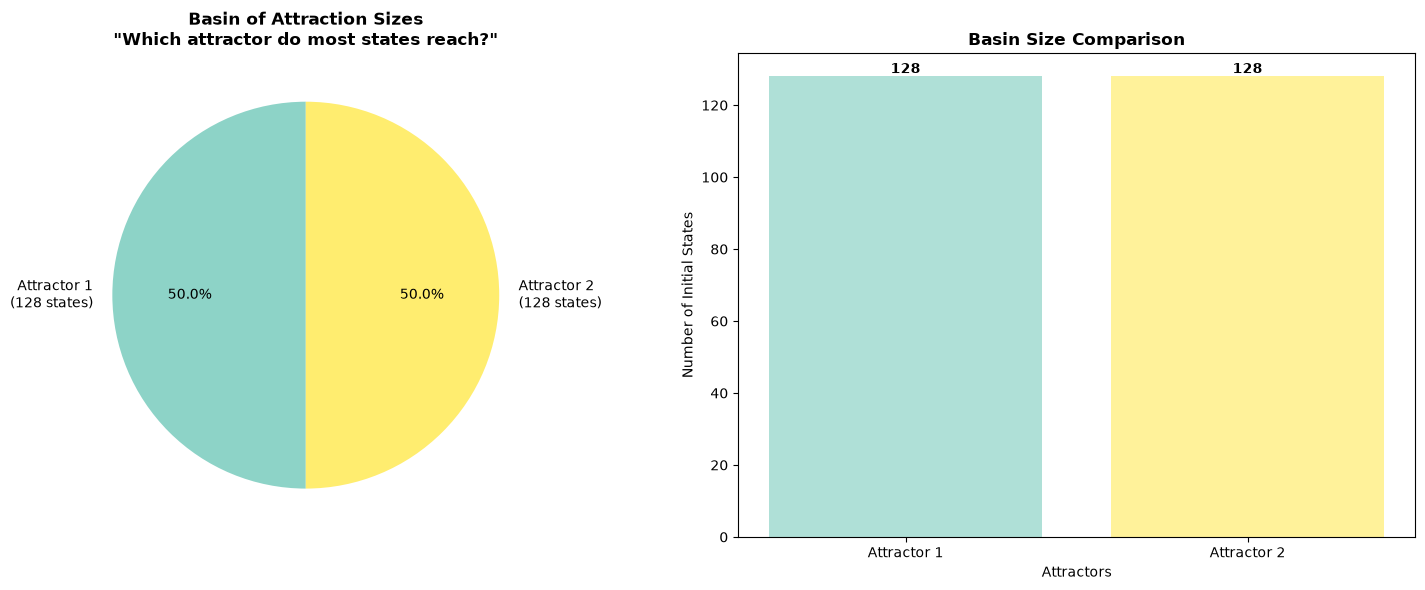

In [ ]:
# Track which initial states lead to which attractors
basin_data = defaultdict(list)  # attractor -> list of initial states
attractor_map = {}  # initial_state -> attractor_index

n_nodes = len(node_names)
all_states = list(product([0, 1], repeat=n_nodes))
print(f"Analyzing {len(all_states)} initial states...")

for initial_state in all_states:
    # Set network state
    state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
    network.set_state(**state_dict)

    # Simulate
    trajectory = network.simulate(steps=max_steps, record_history=True)

    # Find which attractor this leads to
    if len(trajectory) >= 2 and np.array_equal(trajectory[-1], trajectory[-2]):
        final_state = tuple(int(x) for x in trajectory[-1])  # Clean conversion

        # Find matching attractor
        for att_idx, attractor in enumerate(attractors):
            clean_attractor = tuple(int(x) for x in attractor)
            if final_state == clean_attractor:
                basin_data[att_idx].append(initial_state)
                attractor_map[initial_state] = att_idx
                break

# Display basin sizes
print(f"\n Basin Sizes:")
total_states = len(all_states)
for att_idx in range(len(attractors)):
    basin_size = len(basin_data[att_idx])
    percentage = (basin_size / total_states) * 100
    print(f"   Attractor {att_idx + 1}: {basin_size:3d} states ({percentage:5.1f}%)")

# Create pie chart of basin sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart of basin sizes
basin_sizes = [len(basin_data[i]) for i in range(len(attractors))]
basin_labels = [f'Attractor {i + 1}\n({size} states)' for i, size in enumerate(basin_sizes)]
colors = plt.cm.Set3(np.linspace(0, 1, len(attractors)))

wedges, texts, autotexts = ax1.pie(basin_sizes,
                                   labels=basin_labels,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)

ax1.set_title('Basin of Attraction Sizes\n"Which attractor do most states reach?"',
              fontsize=12, fontweight='bold')

# Bar chart comparison
attractor_names = [f'Attractor {i + 1}' for i in range(len(attractors))]
bars = ax2.bar(attractor_names, basin_sizes, color=colors, alpha=0.7)

ax2.set_title('Basin Size Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Initial States', fontsize=10)
ax2.set_xlabel('Attractors', fontsize=10)

# Add value labels on bars
for bar, size in zip(bars, basin_sizes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2., height, f'{size}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Analysis: Two steady states were found, with the only difference being the DNA damage state. In both attractors, MYC, MDM2, CDK2 and Growth are ON, while p53, p21 and Death are OFF. Each attractor is reached by 128 of the 256 possible initial states, so each has a basin size of 50%. Since both attractors are cancer-like, 100% of the initial states lead to a cancer-like state.

### Testing the Third mutation: MDM2 overexpression

Scenario analysis

In [ ]:
# 🟡 Example code for healthy cell below, adapt to also run Stressed Cell and Oncogene Hijacked Cell scenarios

scenarios = {
    'Healthy Cell': {'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Stressed Cell': { 'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Oncogene Hijacked Cell': { 'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}
}

results = {}
# Degine MDM2 overexpression mutation
network.add_rule('MDM2', lambda s: True, "MDM2 = OVEREXPRESSED (always ON)")

for s in scenarios:
    initial_state = scenarios[s]
    network.set_state(**initial_state)
    trajectory = network.simulate(steps=8)
    results[s] = trajectory

    final_state = trajectory[-1]
    node_names = sorted(network.nodes.keys())
    final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

    print(f"   {s}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")




   Reached steady state after 4 steps
   Healthy Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 6 steps
   Stressed Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 3 steps
   Oncogene Hijacked Cell: Final state: Growth=1, Death=0, p53=0


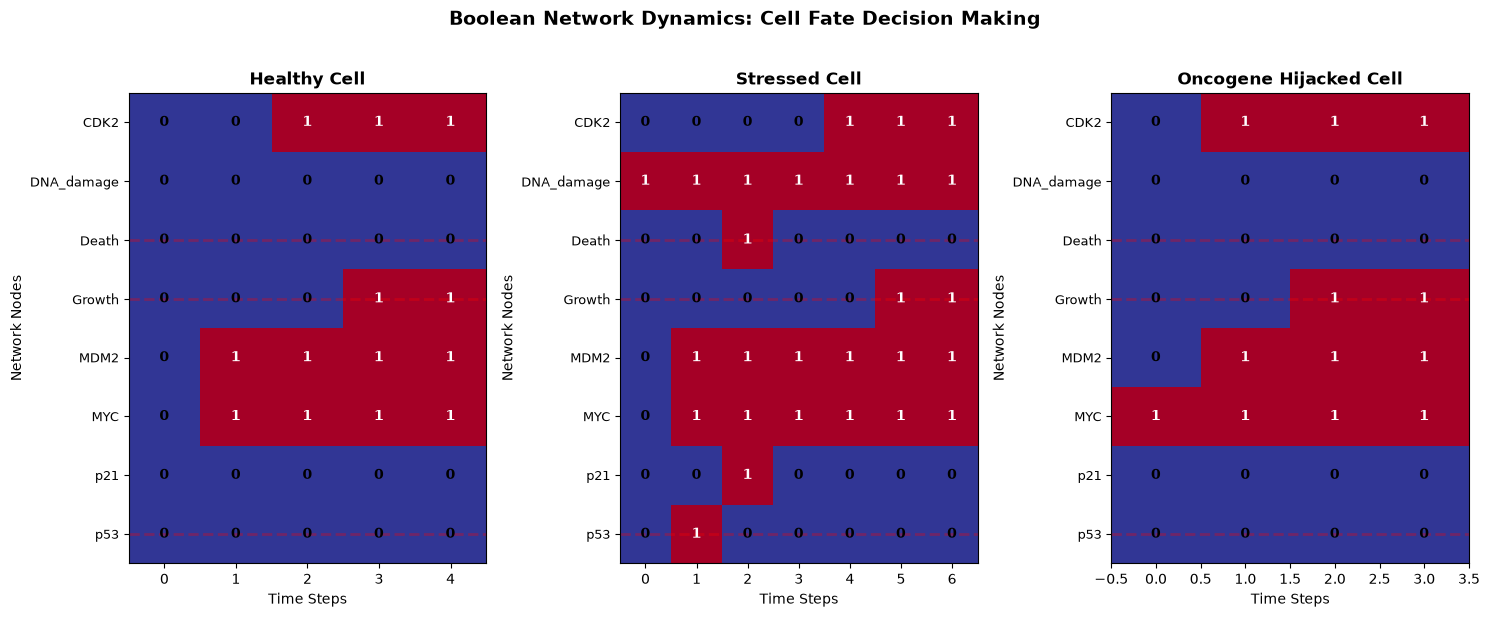

In [ ]:
# 🟢 Visualize results
n_scenarios = len(results)
fig, axes = plt.subplots(1, n_scenarios, figsize=(5*n_scenarios, 6))

if n_scenarios == 1:
    axes = [axes]

for scenario_idx, (scenario_name, trajectory) in enumerate(results.items()):
    ax = axes[scenario_idx]

    # Create heatmap
    trajectory_matrix = trajectory.T  # Transpose for proper orientation

    im = ax.imshow(trajectory_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')

    # Formatting
    ax.set_title(f'{scenario_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Time Steps', fontsize=10)
    ax.set_ylabel('Network Nodes', fontsize=10)
    ax.set_yticks(range(len(node_names)))
    ax.set_yticklabels(node_names, fontsize=9)

    # Add text annotations
    for t in range(trajectory.shape[0]):
        for n in range(len(node_names)):
            color = 'white' if trajectory_matrix[n, t] == 1 else 'black'
            ax.text(t, n, int(trajectory_matrix[n, t]),
                   ha="center", va="center", color=color, fontweight='bold')

    # Highlight key output nodes
    output_indices = [i for i, name in enumerate(node_names) if name in ['Growth', 'Death', 'p53']]
    for output_idx in output_indices:  # Changed variable name to avoid conflict
        ax.axhline(y=output_idx, color='red', linestyle='--', alpha=0.3, linewidth=2)

plt.suptitle('Boolean Network Dynamics: Cell Fate Decision Making',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


The cell achieves a state of growth, as well as sustained activation of CDK2, MDM2 and MYC regardless of DNA_damage leading the cell to potentially become cancerous.

Attractor analysis

In [ ]:
import itertools

# 🟡 Let's find the attractor states

attractors = []
max_steps=15
node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

print(f"Testing all {2**n_nodes} possible initial states...")

# TODO: Generate all possible initial states
# Hint: Use itertools.product([0, 1], repeat=n_nodes)
all_states = []
for state in itertools.product([0,1], repeat=n_nodes):
    state = dict(zip(node_names, state))
    all_states.append(state)




for initial_state in all_states:
  # Set the network to this initial state
  #state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
  network.set_state(**initial_state)

  # TODO: Simulate the network
  trajectory = network.simulate(steps=max_steps)

  # Check if it reached a steady state (last two states are the same)
  if len(trajectory) >= 2:
    final_state = tuple(trajectory[-1])  # Convert to tuple for comparison

  # Check if this is a new attractor
    if np.array_equal(trajectory[-1], trajectory[-2]):  # Steady state reached
      if final_state not in attractors:
        attractors.append(final_state)

Testing all 256 possible initial states...
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reac


FOUND 2 ATTRACTORS:

Attractor 1: [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: OFF
   → 

Attractor 2: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: ON
   → 


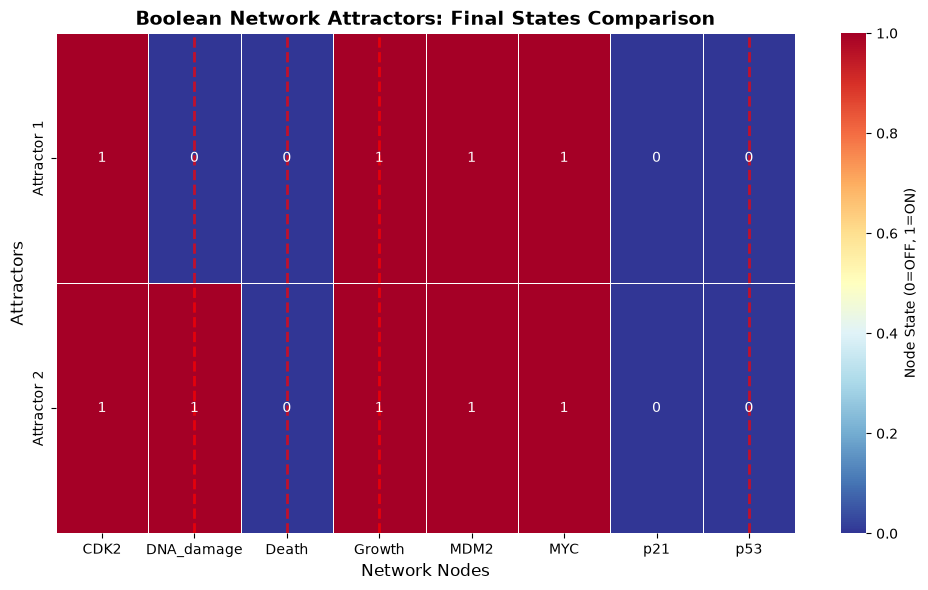

In [ ]:
# 🟡 Let's find the attractor states

print(f"\nFOUND {len(attractors)} ATTRACTORS:")

for i, attractor in enumerate(attractors):
        print(f"\nAttractor {i+1}: {list(attractor)}")

        # Create state dictionary for easy access
        state_dict = {node_names[j]: attractor[j] for j in range(len(node_names))}

        # Analyze the biological meaning
        growth_active = state_dict['Growth'] == 1
        death_active = state_dict['Death'] == 1
        p53_active = state_dict['p53'] == 1
        dna_damage_active = state_dict['DNA_damage'] == 1


        print(f"   Growth: {'ON' if growth_active else 'OFF'}")
        print(f"   Death: {'ON' if death_active else 'OFF'}")
        print(f"   p53: {'ON' if p53_active else 'OFF'}")
        print(f"   DNA Damage: {'ON' if dna_damage_active else 'OFF'}")

        # TODO: Interpret the meaning
        if growth_active and not death_active and not dna_damage_active:
            interpretation = ""
        elif death_active and not growth_active:
            interpretation = ""
        elif growth_active and not death_active and dna_damage_active:
            interpretation = ""
        else:
            interpretation = "CONFLICT - Unusual state"

        print(f"   → {interpretation}")


# Convert attractors to clean matrix
attractor_matrix = []
for attractor in attractors:
    clean_row = [int(x) for x in attractor]
    attractor_matrix.append(clean_row)

attractor_matrix = np.array(attractor_matrix)

# Create heatmap
plt.figure(figsize=(10, max(6, len(attractors))))

# Create heatmap with custom colors
ax = sns.heatmap(attractor_matrix,
                 xticklabels=node_names,
                 yticklabels=[f'Attractor {i+1}' for i in range(len(attractors))],
                 cmap='RdYlBu_r',
                 cbar_kws={'label': 'Node State (0=OFF, 1=ON)'},
                 annot=True,
                 fmt='d',
                 linewidths=0.5)

plt.title('Boolean Network Attractors: Final States Comparison',
          fontsize=14, fontweight='bold')
plt.xlabel('Network Nodes', fontsize=12)
plt.ylabel('Attractors', fontsize=12)

# Highlight key output nodes
output_nodes = ['Growth', 'Death', 'p53', 'DNA_damage']
for node in output_nodes:
    if node in node_names:
        idx = node_names.index(node)
        ax.axvline(x=idx+0.5, color='red', linestyle='--', alpha=0.7, linewidth=2)

plt.tight_layout()
plt.show()

Analyzing 256 initial states...
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady 

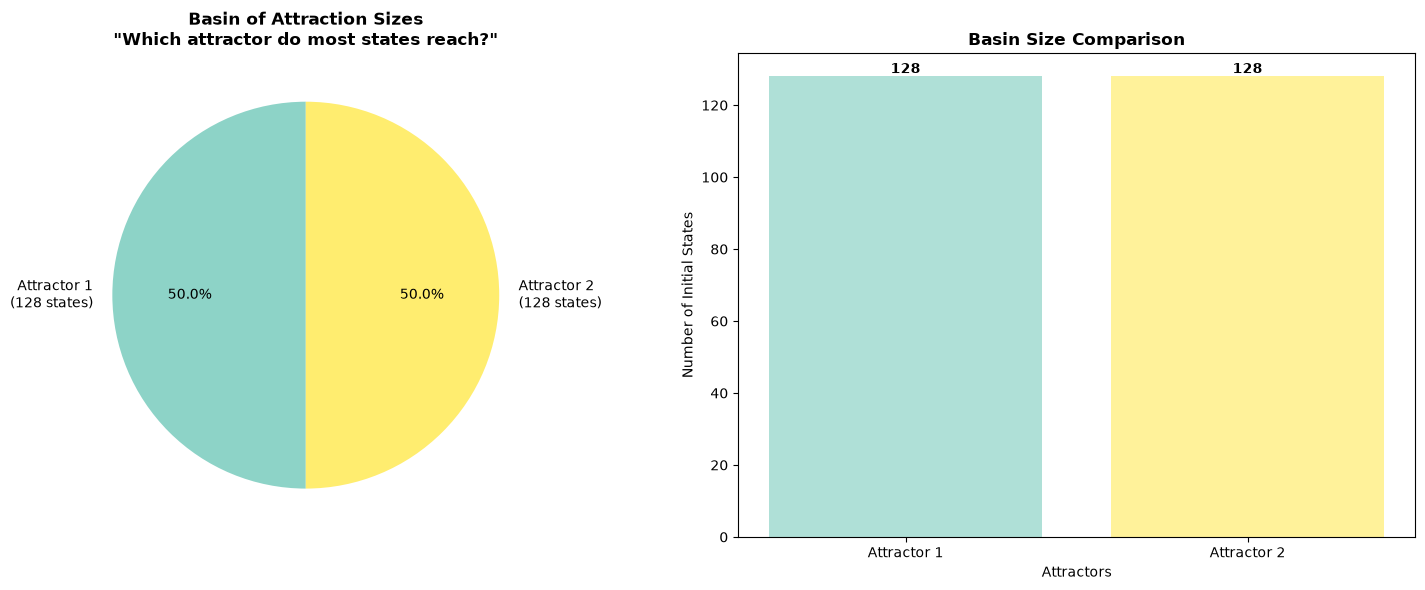

0


In [ ]:
# 🟡 Which states end up in which attractor?

# Track which initial states lead to which attractors
basin_data = defaultdict(list)  # attractor -> list of initial states
attractor_map = {}  # initial_state -> attractor_index

n_nodes = len(node_names)
all_states = list(product([0, 1], repeat=n_nodes))
print(f"Analyzing {len(all_states)} initial states...")

max = 0

for initial_state in all_states:
    # Set network state
    state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
    network.set_state(**state_dict)

    # Simulate
    trajectory = network.simulate(steps=max_steps, record_history=True)
    if len(trajectory) == 8:
        max +=1


    # Find which attractor this leads to
    if len(trajectory) >= 2 and np.array_equal(trajectory[-1], trajectory[-2]):
        final_state = tuple(int(x) for x in trajectory[-1])  # Clean conversion

        # Find matching attractor
        for att_idx, attractor in enumerate(attractors):
            clean_attractor = tuple(int(x) for x in attractor)
            if final_state == clean_attractor:
                basin_data[att_idx].append(initial_state)
                attractor_map[initial_state] = att_idx
                break

# Display basin sizes
print(f"\n Basin Sizes:")
total_states = len(all_states)
for att_idx in range(len(attractors)):
    basin_size = len(basin_data[att_idx])
    percentage = (basin_size / total_states) * 100
    print(f"   Attractor {att_idx+1}: {basin_size:3d} states ({percentage:5.1f}%)")

# Create pie chart of basin sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart of basin sizes
basin_sizes = [len(basin_data[i]) for i in range(len(attractors))]
basin_labels = [f'Attractor {i+1}\n({size} states)' for i, size in enumerate(basin_sizes)]
colors = plt.cm.Set3(np.linspace(0, 1, len(attractors)))

wedges, texts, autotexts = ax1.pie(basin_sizes,
                                   labels=basin_labels,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)

ax1.set_title('Basin of Attraction Sizes\n"Which attractor do most states reach?"',
              fontsize=12, fontweight='bold')

# Bar chart comparison
attractor_names = [f'Attractor {i+1}' for i in range(len(attractors))]
bars = ax2.bar(attractor_names, basin_sizes, color=colors, alpha=0.7)

ax2.set_title('Basin Size Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Initial States', fontsize=10)
ax2.set_xlabel('Attractors', fontsize=10)

# Add value labels on bars
for bar, size in zip(bars, basin_sizes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{size}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(max)

Two attractors were found as dictated by the state of DNA_damage. Overexpression of MDM2 directly prevents p53 from from activating while fueling the expression of MYC, followed by CDK2 subsequently leading to cell growth in every case. Prevention of cell death means the cell will become cancerous whenever DNA damage occurs. This process differs from similar mutation mainly in terms of speed as 25% of the simulations reach steady state after as much as 7 steps.

### Testing the Fourth mutation: p21 OFF + MYC ON

In [ ]:
network = reset_network()
network.add_rule('p21', lambda s: False, "p21 = OFF")
network.add_rule('MYC', lambda s: True, "MYC = ON")

print("Rules:")
for node, rule_info in network.rules.items():
    print(f" {rule_info['description']}")

Rules:
 DNA_damage = INPUT (constant)
 p21 = OFF
 MYC = ON
 CDK2 = MYC AND (NOT p21) AND (NOT p53)
 MDM2 = MYC
 p53 = DNA_damage AND (NOT MDM2)
 Growth = CDK2 AND MYC AND (NOT p53)
 Death = p53 AND DNA_damage AND (NOT Growth)


In [ ]:
scenarios = {
    'Healthy Cell': {'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Stressed Cell': { 'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Oncogene Hijacked Cell': { 'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}
}

results = {}

s1 = "Healthy Cell"
s2 = "Stressed Cell"
s3 = "Oncogene Hijacked Cell"

for s in [s1, s2, s3]:
    initial_state = scenarios[s]

    network.set_state(**initial_state)
    trajectory = network.simulate(steps=8)
    results[s] = trajectory

    final_state = trajectory[-1]
    node_names = sorted(network.nodes.keys())
    final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

    print(f"{s}: Final state:Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")

   Reached steady state after 4 steps
Healthy Cell: Final state:Growth=1, Death=0, p53=0
   Reached steady state after 6 steps
Stressed Cell: Final state:Growth=1, Death=0, p53=0
   Reached steady state after 3 steps
Oncogene Hijacked Cell: Final state:Growth=1, Death=0, p53=0


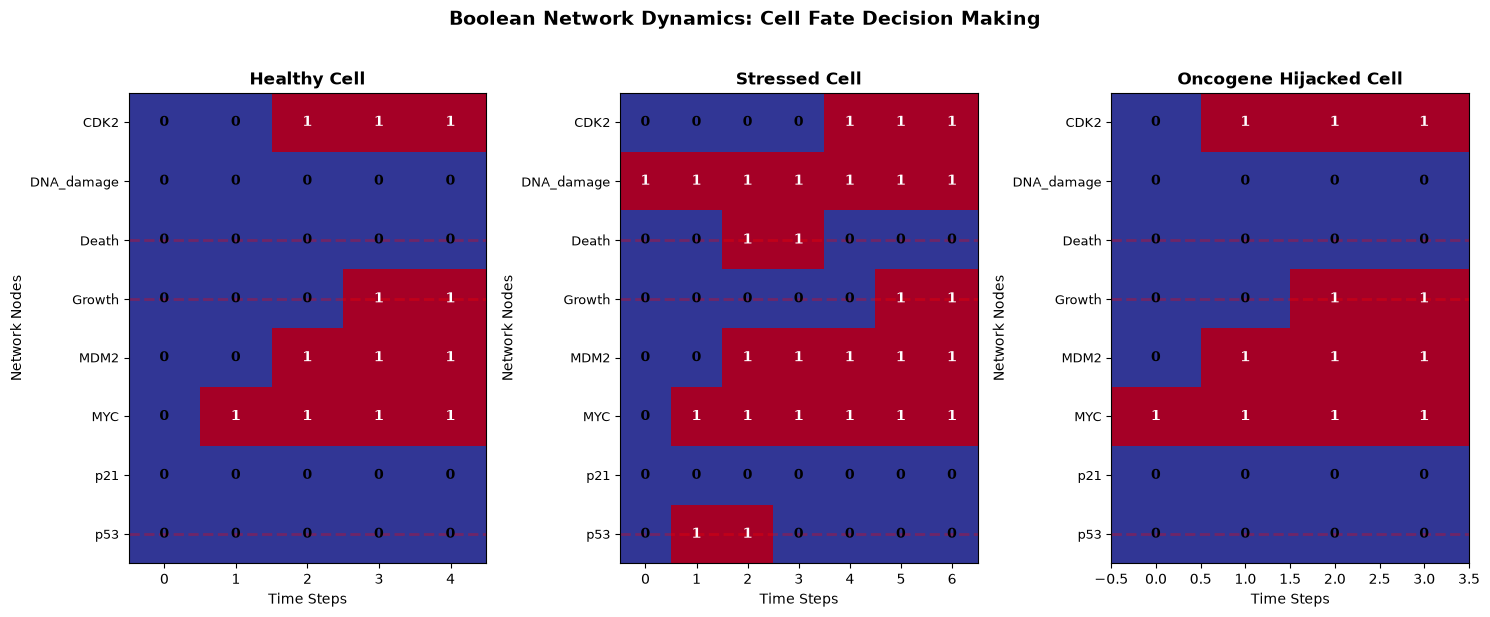

In [ ]:
#my charts are copies of the above charts
n_scenarios = len(results)
fig, axes = plt.subplots(1, n_scenarios, figsize=(5*n_scenarios, 6))

if n_scenarios == 1:
    axes = [axes]

for scenario_idx, (scenario_name, trajectory) in enumerate(results.items()):
    ax = axes[scenario_idx]

    # Create heatmap
    trajectory_matrix = trajectory.T  # Transpose for proper orientation

    im = ax.imshow(trajectory_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')

    # Formatting
    ax.set_title(f'{scenario_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Time Steps', fontsize=10)
    ax.set_ylabel('Network Nodes', fontsize=10)
    ax.set_yticks(range(len(node_names)))
    ax.set_yticklabels(node_names, fontsize=9)

    # Add text annotations
    for t in range(trajectory.shape[0]):
        for n in range(len(node_names)):
            color = 'white' if trajectory_matrix[n, t] == 1 else 'black'
            ax.text(t, n, int(trajectory_matrix[n, t]),
                   ha="center", va="center", color=color, fontweight='bold')

    # Highlight key output nodes
    output_indices = [i for i, name in enumerate(node_names) if name in ['Growth', 'Death', 'p53']]
    for output_idx in output_indices:
        ax.axhline(y=output_idx, color='red', linestyle='--', alpha=0.3, linewidth=2)

plt.suptitle('Boolean Network Dynamics: Cell Fate Decision Making',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Analysis
In the heatmaps the p21 row stays blue for every scenario and all three cells end in the same red block of MYC, MDM2, CDK2 and growth. The healthy cell needs 4 steps and mutated cell only 3, since MYC is already ON at t=0. The stressed cell however has p53 ON at steps 1-2 and death at steps 2-33, but once MDM2 turns ON at step 2 it pushes p53 back to OFF, death disappears and growth takes over from step 5. The damage response is started but gets overruled.

##### Attractor analysis

In [ ]:
import itertools

attractors = []
max_steps = 15
node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

print(f"Testing all {2 ** n_nodes} possible initial states...")

all_states = itertools.product([0, 1], repeat=n_nodes)

for initial_state in all_states:
    # Set the network to this initial state
    state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
    network.set_state(**state_dict)

    # Simulate the network
    trajectory = network.simulate(steps=max_steps)

    # Check if it reached a steady state (last two states are the same)
    if len(trajectory) >= 2:
        final_state = tuple(trajectory[-1])  # Convert to tuple for comparison

        if np.array_equal(trajectory[-1], trajectory[-2]):  # Steady state reached
            if final_state not in attractors:
                attractors.append(final_state)

Testing all 256 possible initial states...
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 3 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 3 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 3 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reac


FOUND 2 ATTRACTORS:

Attractor 1: [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: OFF
   → Cancer-like growth state

Attractor 2: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: ON
   → Cancer-like growth despite DNA damage


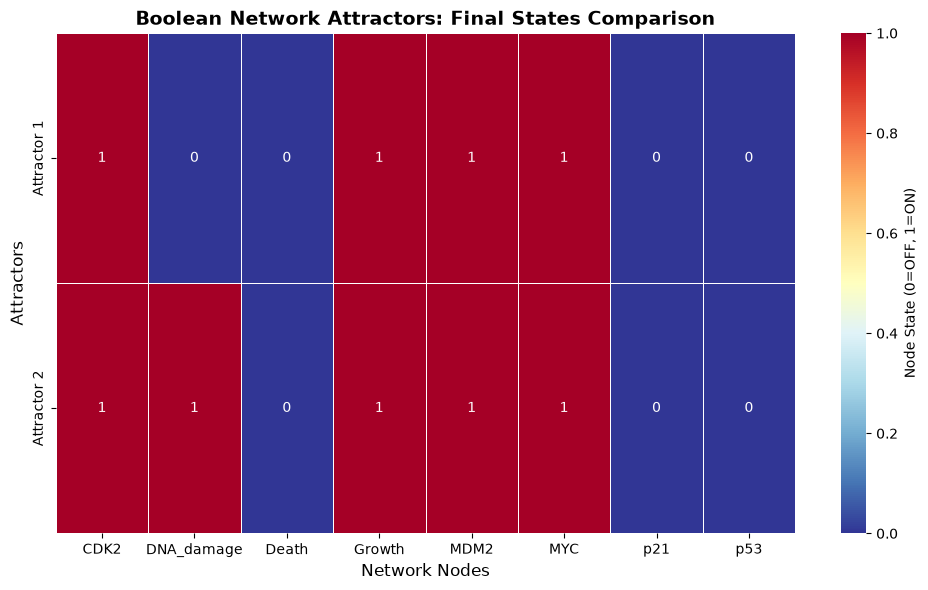

In [ ]:
import builtins #int conversion hack

print(f"\nFOUND {len(attractors)} ATTRACTORS:")

for i, attractor in enumerate(attractors):
    print(f"\nAttractor {i + 1}: {list(attractor)}")

    # Create state dictionary for easy access
    state_dict = {node_names[j]: attractor[j] for j in range(len(node_names))}

    # Analyze the biological meaning
    growth_active = state_dict['Growth'] == 1
    death_active = state_dict['Death'] == 1
    p53_active = state_dict['p53'] == 1
    dna_damage_active = state_dict['DNA_damage'] == 1

    print(f"   Growth: {'ON' if growth_active else 'OFF'}")
    print(f"   Death: {'ON' if death_active else 'OFF'}")
    print(f"   p53: {'ON' if p53_active else 'OFF'}")
    print(f"   DNA Damage: {'ON' if dna_damage_active else 'OFF'}")

    if growth_active and not death_active and not dna_damage_active:
        interpretation = "Cancer-like growth state"
    elif death_active and not growth_active:
        interpretation = "Cell death / protective state"
    elif growth_active and not death_active and dna_damage_active:
        interpretation = "Cancer-like growth despite DNA damage"
    else:
        interpretation = "CONFLICT - Unusual state"

    print(f"   → {interpretation}")

# Convert attractors to clean matrix
attractor_matrix = []
for attractor in attractors:
    clean_row = [int(x) for x in attractor]
    attractor_matrix.append(clean_row)

attractor_matrix = np.array(attractor_matrix)

# Create heatmap
plt.figure(figsize=(10, builtins.max(6, len(attractors))))

ax = sns.heatmap(attractor_matrix,
                 xticklabels=node_names,
                 yticklabels=[f'Attractor {i + 1}' for i in range(len(attractors))],
                 cmap='RdYlBu_r',
                 cbar_kws={'label': 'Node State (0=OFF, 1=ON)'},
                 annot=True,
                 fmt='d',
                 linewidths=0.5)

plt.title('Boolean Network Attractors: Final States Comparison',
          fontsize=14, fontweight='bold')
plt.xlabel('Network Nodes', fontsize=12)
plt.ylabel('Attractors', fontsize=12)

plt.tight_layout()
plt.show()

Analyzing 256 initial states...
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 3 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 3 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 3 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady state after 4 steps
   Reached steady 

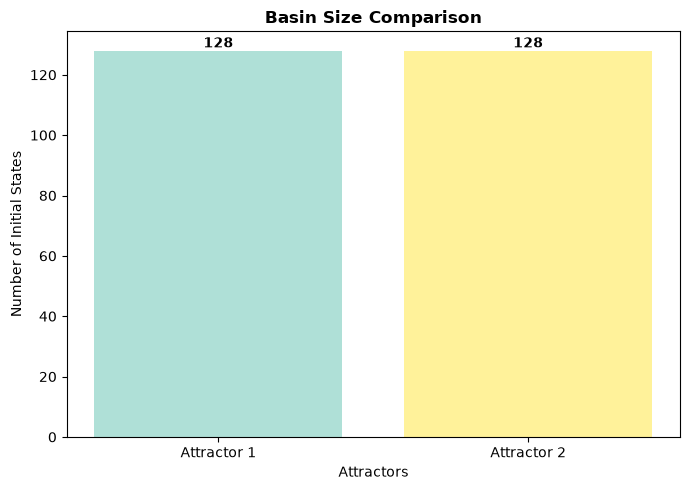

In [ ]:
import builtins

# Track which initial states lead to which attractors
basin_data = defaultdict(list)  # attractor -> list of initial states
attractor_map = {}  # initial_state -> attractor_index
steps_to_steady = []

n_nodes = len(node_names)
all_states = list(product([0, 1], repeat=n_nodes))
print(f"Analyzing {len(all_states)} initial states...")

for initial_state in all_states:
    # Set network state
    state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
    network.set_state(**state_dict)

    # Simulate
    trajectory = network.simulate(steps=max_steps, record_history=True)

    # Find which attractor this leads to
    if len(trajectory) >= 2 and np.array_equal(trajectory[-1], trajectory[-2]):
        final_state = tuple(int(x) for x in trajectory[-1])

        # The last row repeats the steady state, so it was already reached one step earlier
        steps_to_steady.append(len(trajectory) - 2)

        # Find matching attractor
        for att_idx, attractor in enumerate(attractors):
            clean_attractor = tuple(int(x) for x in attractor)
            if final_state == clean_attractor:
                basin_data[att_idx].append(initial_state)
                attractor_map[initial_state] = att_idx
                break

# Display basin sizes
print(f"\n Basin Sizes:")
total_states = len(all_states)
for att_idx in range(len(attractors)):
    basin_size = len(basin_data[att_idx])
    percentage = (basin_size / total_states) * 100
    print(f"   Attractor {att_idx + 1}: {basin_size:3d} states ({percentage:5.1f}%)")

print(f"\nThe slowest initial states needed {builtins.max(steps_to_steady)} steps to reach a steady state")

# Bar chart of basin sizes
basin_sizes = [len(basin_data[i]) for i in range(len(attractors))]
attractor_names = [f'Attractor {i + 1}' for i in range(len(attractors))]
colors = plt.cm.Set3(np.linspace(0, 1, len(attractors)))

plt.figure(figsize=(7, 5))
bars = plt.bar(attractor_names, basin_sizes, color=colors, alpha=0.7)

plt.title('Basin Size Comparison', fontsize=12, fontweight='bold')
plt.ylabel('Number of Initial States', fontsize=10)
plt.xlabel('Attractors', fontsize=10)

# Add value labels on bars
for bar, size in zip(bars, basin_sizes):
    plt.text(bar.get_x() + bar.get_width() / 2., bar.get_height(), f'{size}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

#### Analysis
The attractor heatmap shows 2 steady states and DNA damage is the only column that differs between them. CDK2, growth, MDM2 and MYC are ON in both, death, p21 and p53 are OFF, so both attractors are cancer like. The bar chart shows the two basins are exactly equal, 128 of the 256 initial states each, meaning 100% of the starting states end up growing and half of them keep growing while the DNA is damaged. These are the same attractors as for the MYC amplification alone, so the p21 knockout adds nothing on top. MYC already keeps p53 and therefore p21 OFF by itself. Thus combining p21 OFF with MYC ON does not further alter the networks attractors compared with MYC ON alone.

### Questions

##### Question 1:

##### Question 2: Explain the role of feedback loops (e.g., MYC → MDM2 → p53)
Answer:

//Gonna expand on this later

Inside a healthy cell, p53 as well as the subsequent p21, are responsible for stunting its growth and causing eventual death. However, in case of either sustained overexpression of MDM2/MYC or underexpression of p53, a negative feedback loop gets triggered. MYC leads to expression of MDM2 which inhibits the expression 53, consequently increasing the expression of MYC again. This feedback loop is particularly dangerous, as it prevents apoptosis and stimulates growth regardless of the damage to the DNA, leading to the cell potentially becoming cancerous.



##### Question 3: What are the limitations of this Boolean network model? Discuss 3 specific limitations.

Answer: 
1) Genes are represented as either on or off, so we lose information about potential in-between situations (where states are in a state of balance between 0 and 1).
2) The time it takes to go from one state to the other is also disregarded, only the discrete states are preserved.
3) In this specific Boolean model, we need to specify a number of steps we want to simulate and hope that the steady state lies below that number. There is no function to automatically find the number of steps it takes to reach a steady state or to identify whether the state is unstable and how long is the potential cycle.


# sounds fun!!!

## HECK YEAH!